In [1]:
import rebound
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.integrate import quad

In [2]:
#copyting my function from last's week's work to get the analytically calculated frequencies using secular threory as outlined in chapter 7

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  

In [3]:
#fourrier transform functions

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def hk_ft(times,pomega,ecc):
    h = ecc*np.sin(pomega)
    f,pxx = ft(times, h)
    return f,pxx

def ecc_ft(times,ecc):
    f,pxx = ft(times, ecc)
    return f,pxx

## Exploration Near 2:1 MMR

[3.55301323e-05 3.82544932e-06]


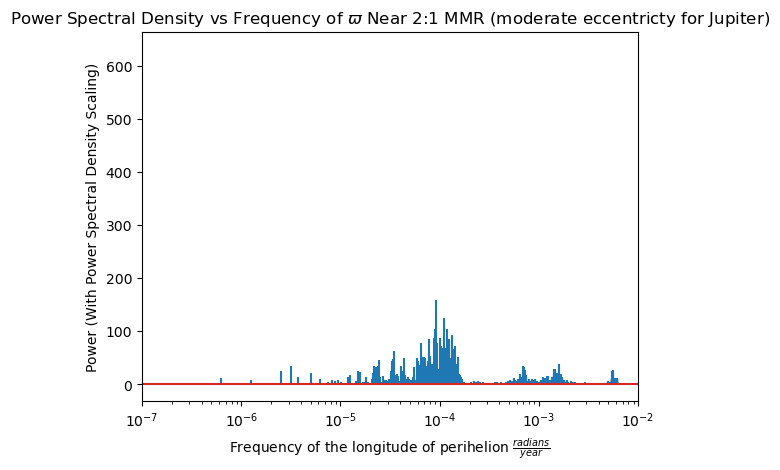

In [4]:
#aiming for values in the range of what the paper suggested
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
#plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Analytically predict')
#plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (moderate eccentricty for Jupiter)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


/home/miaed/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


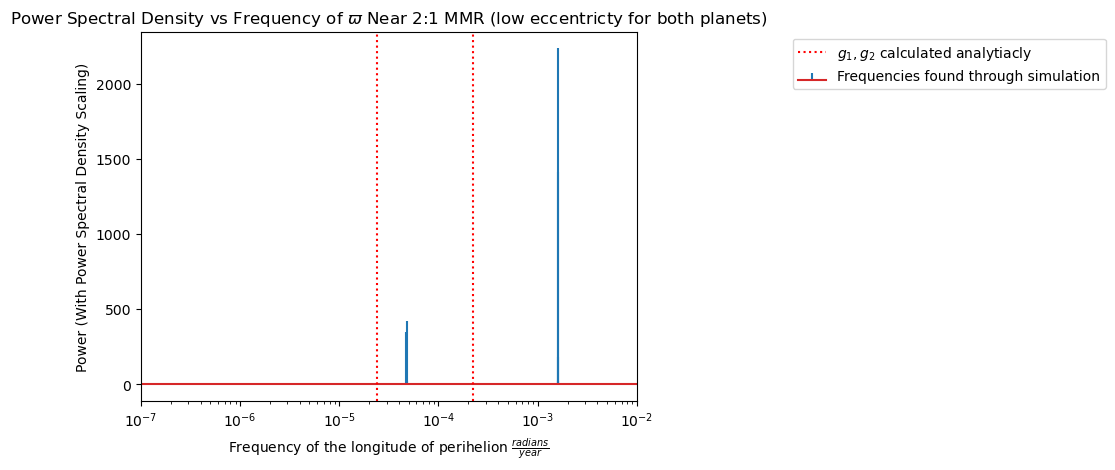

In [5]:
#attempting the same simulation with very low eccentricities

sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.01,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.01,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = r'$g_1,g_2$ calculated analytiacly')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (low eccentricty for both planets)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


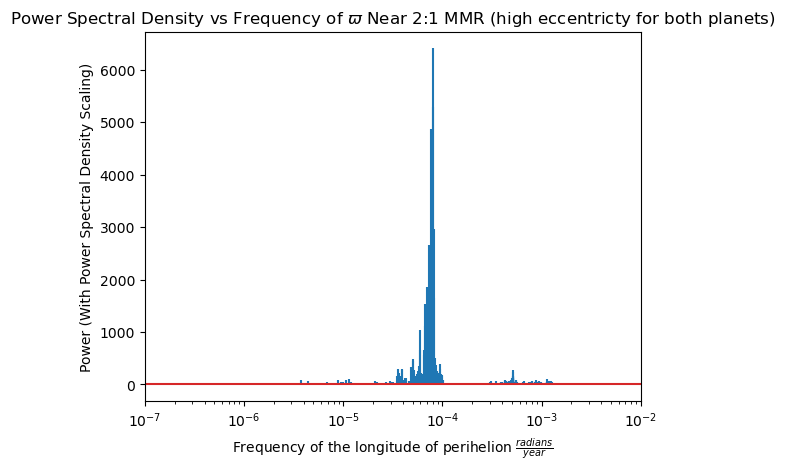

In [7]:
#the same simulation eccept at higher eccentricities

sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.1,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
#plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Frequencies calculated by hand')
#plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (high eccentricty for both planets)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


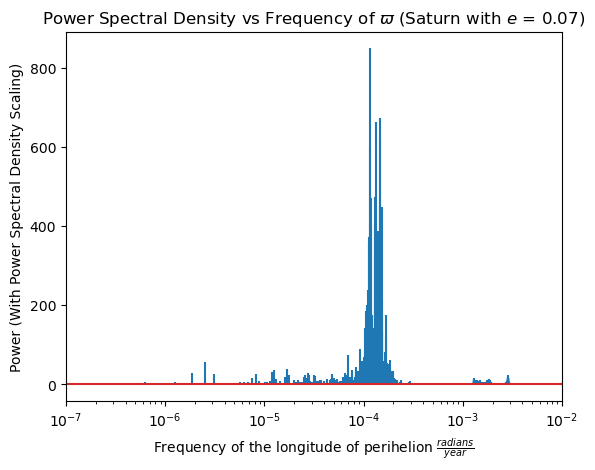

In [12]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.07,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = r'$g_1,g_2$ found through analytically')
plt.xscale('log')
#plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Frequencies calculated by hand')
#plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ (Saturn with $e$ = 0.07)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


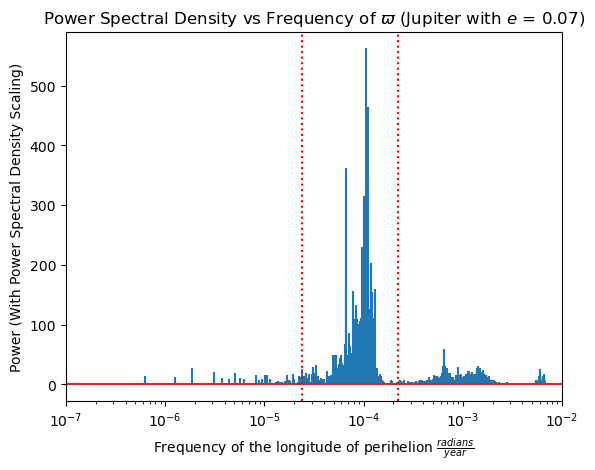

In [13]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.07,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.02,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Frequencies calculated by hand')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ (Jupiter with $e$ = 0.07)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


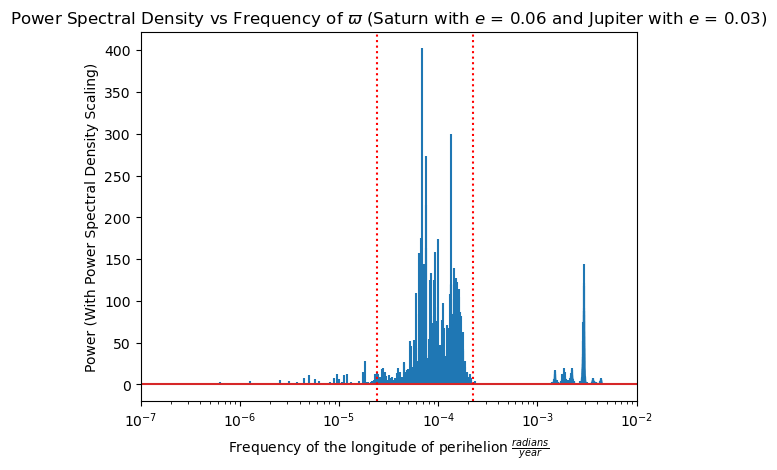

In [10]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.03,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Frequencies calculated by hand')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ (Saturn with $e$ = 0.06 and Jupiter with $e$ = 0.03)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()